In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('cleaned_data.csv')
df.head()

,area,room,living_room,age,floor,city,district,neighbourhood,price
0,300,5,1,0,1,istanbul,kadikoy,caddebostan,5900
1,300,5,2,32,8,istanbul,sisli,tesvikiye,2500
2,300,5,2,32,8,istanbul,sisli,tesvikiye,2500
3,170,2,1,21,0,istanbul,besiktas,etiler,2500
4,130,3,1,1,10,istanbul,kadikoy,goztepe,125000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7727 entries, 0 to 7726
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   area           7727 non-null   int64 
 1   room           7727 non-null   int64 
 2   living_room    7727 non-null   int64 
 3   age            7727 non-null   int64 
 4   floor          7727 non-null   int64 
 5   city           7727 non-null   object
 6   district       7727 non-null   object
 7   neighbourhood  7727 non-null   object
 8   price          7727 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 543.4+ KB


In [4]:
df['city'] = df['city'].astype('category')
df['district'] = df['district'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')


In [5]:
columns = df.select_dtypes(include=[np.number]).columns
min_values = []
max_values = []
for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    min_value = Q1 - 1.5 * IQR
    max_value = Q3 + 1.5 * IQR
    min_values.append(min_value)
    max_values.append(max_value)
    print(f"{column}: Min Value = {min_value}, Max Value = {max_value}")

area: Min Value = -7.5, Max Value = 212.5
room: Min Value = 0.5, Max Value = 4.5
living_room: Min Value = 1.0, Max Value = 1.0
age: Min Value = -26.5, Max Value = 57.5
floor: Min Value = -5.0, Max Value = 11.0
price: Min Value = -24686.25, Max Value = 110811.75


In [6]:
for column in columns:
    print(column)

area
room
living_room
age
floor
price


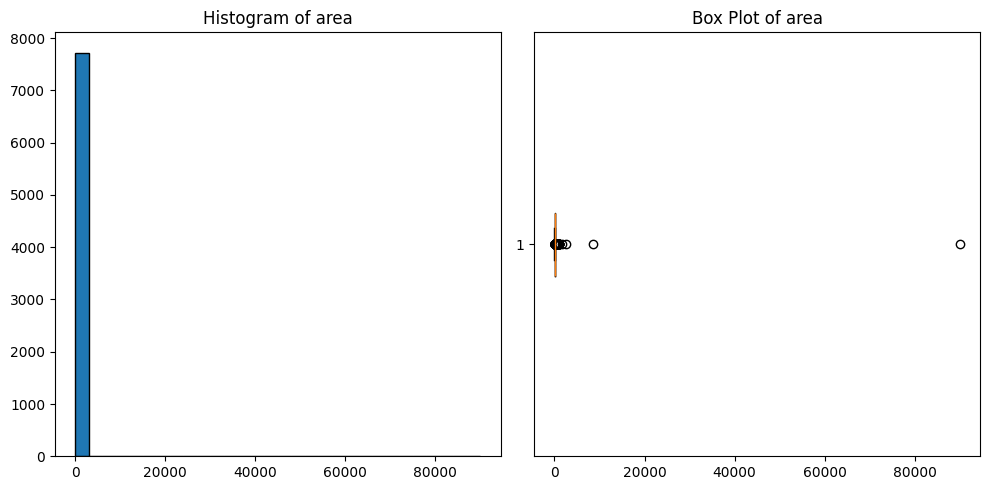

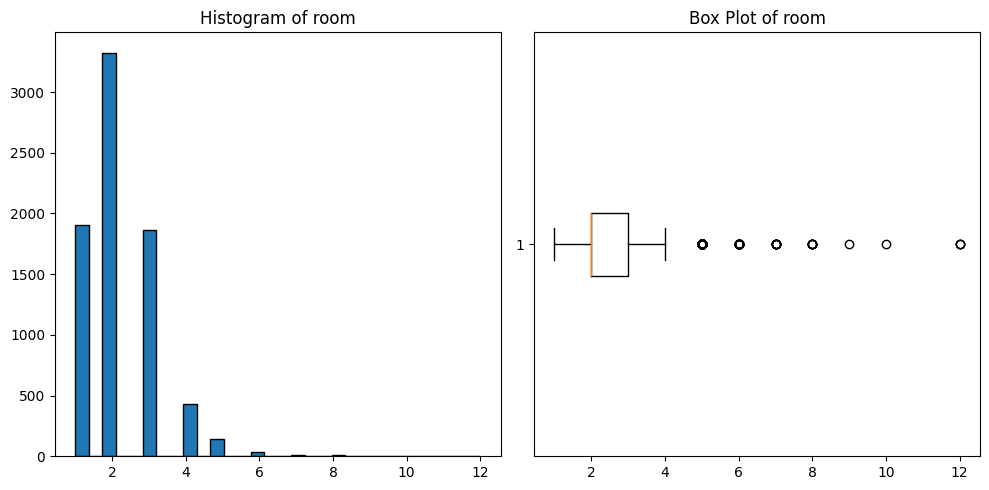

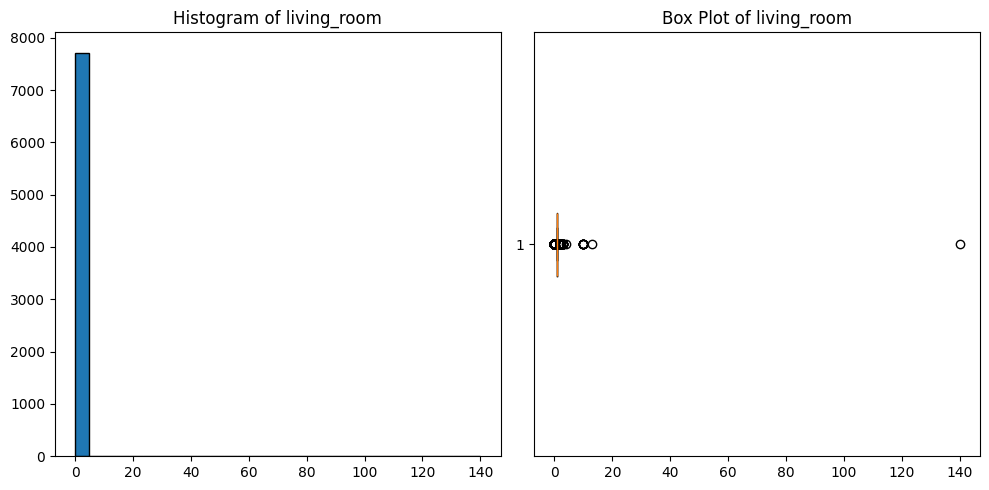

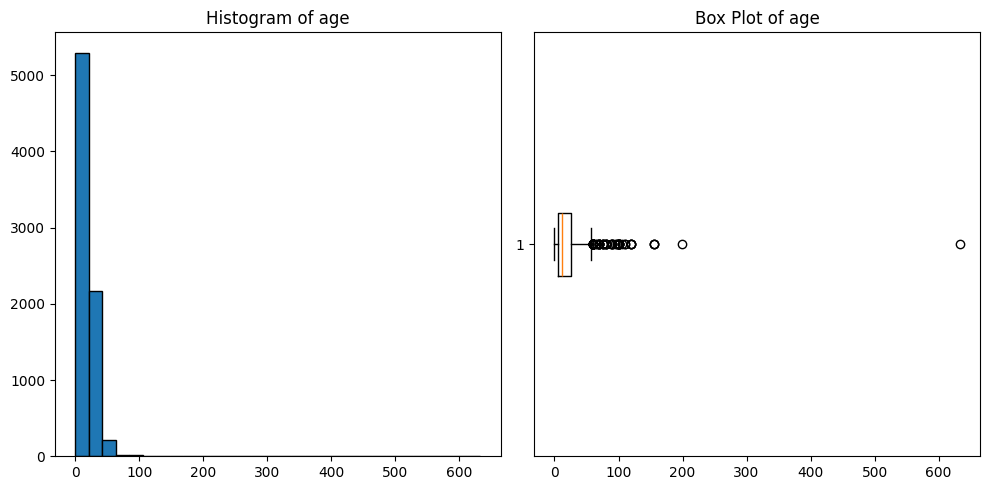

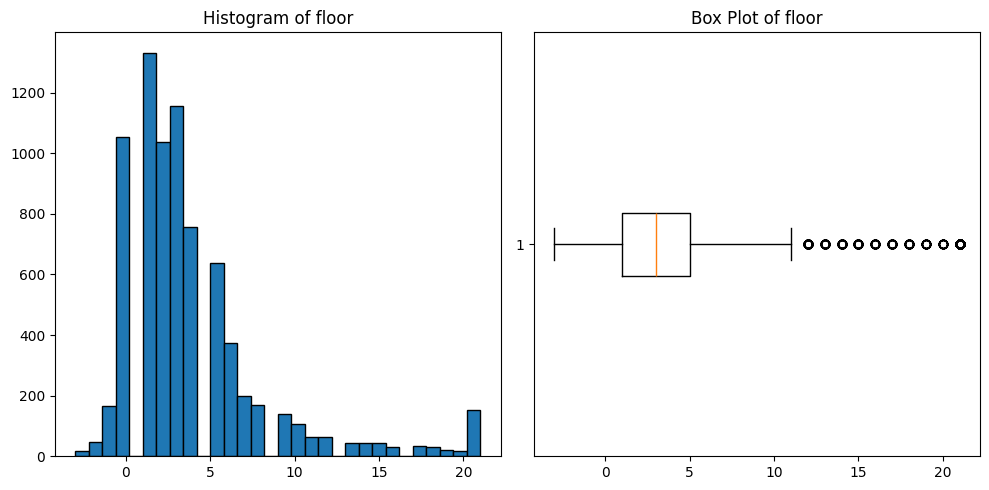

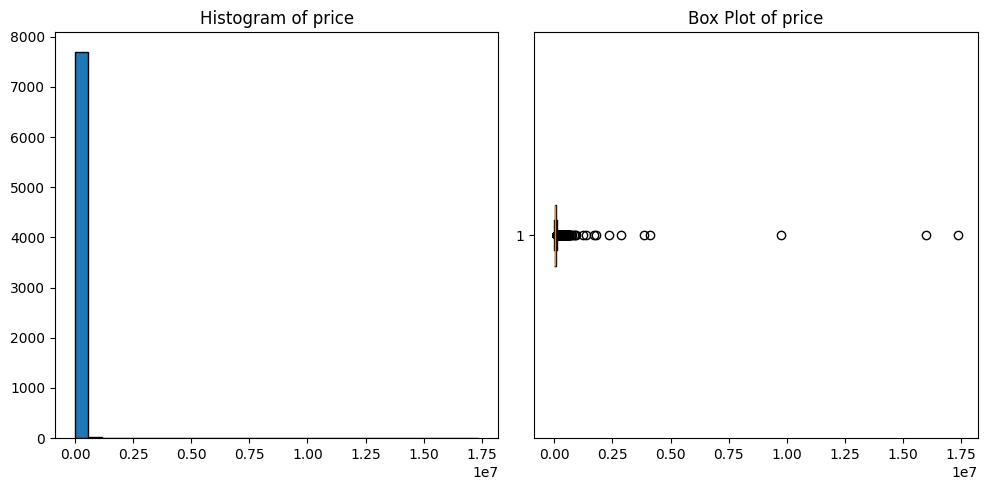

In [7]:
for column in columns:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(df[column], bins=30, edgecolor='k')
    plt.title(f'Histogram of {column}')
    plt.subplot(1, 2, 2)
    plt.boxplot(df[column], vert=False)
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
    plt.show()

In [8]:
for i ,column in enumerate(columns):
    df = df[(df[column] >= min_values[i]) & (df[column] <= max_values[i])]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6060 entries, 3 to 7726
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area           6060 non-null   int64   
 1   room           6060 non-null   int64   
 2   living_room    6060 non-null   int64   
 3   age            6060 non-null   int64   
 4   floor          6060 non-null   int64   
 5   city           6060 non-null   category
 6   district       6060 non-null   category
 7   neighbourhood  6060 non-null   category
 8   price          6060 non-null   int64   
dtypes: category(3), int64(6)
memory usage: 377.1 KB


In [10]:
df.describe()

,area,room,living_room,age,floor,price
count,6060.000000,6060.000000,6060.0,6060.000000,6060.000000,6060.000000
mean,99.137789,2.058911,1.0,15.712706,2.834323,40667.446040
std,32.141701,0.758075,0.0,12.794959,2.568991,20686.372787
min,15.000000,1.000000,1.0,0.000000,-3.000000,2500.000000
25%,75.000000,2.000000,1.0,5.000000,1.000000,25750.000000
50%,92.000000,2.000000,1.0,11.000000,2.000000,35000.000000
75%,120.000000,3.000000,1.0,26.000000,4.000000,50000.000000
max,210.000000,4.000000,1.0,57.000000,11.000000,110000.000000


In [11]:
df.to_csv('analysed_data.csv', index=False)